In [3]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [4]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.204,2041.404],
    [2047.4961,2047.6481],
    [2051.4334,2051.6652],
    [2053.416,2053.715],
    [2058.108,2058.276],
    [2037.663,2037.787],
    [2058.8291,2058.8768],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.82051, 2039.84413],
    [2039,1769,2039.2141],
    [2039.3400,2039.3707],
    [2039.3442,2039.4500],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2051.438,2051.772],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.5068, 2047.6352],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2058.8328,2058.8928],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.8243, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.8317,2058.8757],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

#flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=True, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
#x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
#y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd[1].flux_err, dtype=np.float64)

flcd = lc2_m.flatten(window_length=350, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

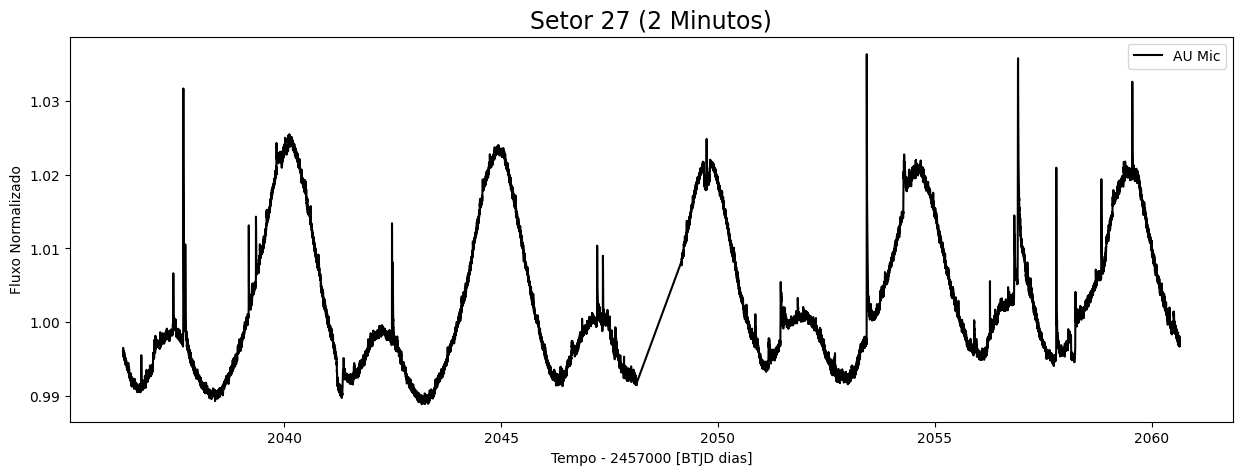

In [5]:

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plot dos dados originais
ax.plot(x2min, y2min, 'k-', label='AU Mic')

# Plot da tendência ajustada
#ax.plot(x_detrend,y_detrend, linewidth=3, label="Ajuste")

ax.set_title('Setor 27 (2 Minutos)', fontsize=17)
ax.set_ylabel("Fluxo Normalizado")
ax.set_xlabel("Tempo - 2457000 [BTJD dias]")

# Adicione outras configurações do gráfico, se necessário

ax.legend()
plt.show()

In [6]:
flcd.to_fits(path='lightcurve_02.fits', overwrite=True)
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_02.fits')
type(hdu)

from astropy.table import Table
dat = Table.read('lightcurve_02.fits', format='fits')
df = dat.to_pandas()
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
#print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [7]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

<IPython.core.display.Javascript object>


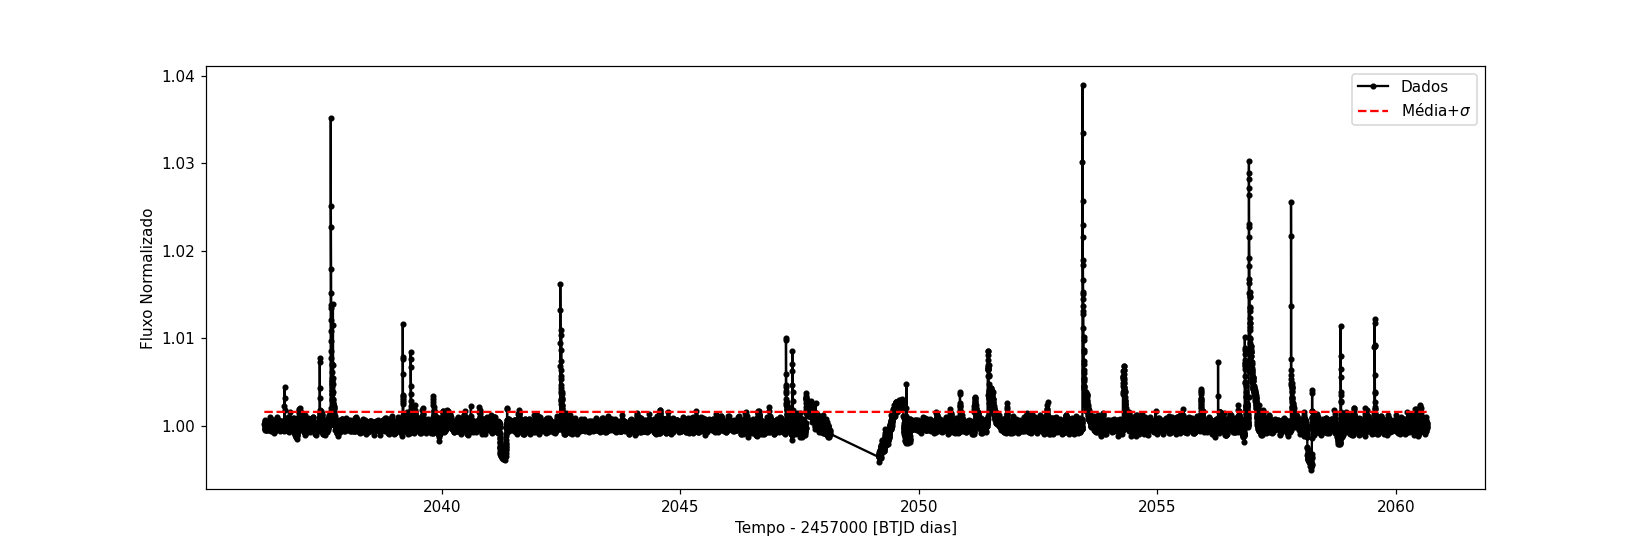

In [16]:
%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

In [15]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 2039.3465
stop_input = 2039.3710

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

[1.0001343 1.0002658 1.0084665 1.007584  1.0067239 1.0045534 1.0035925
 1.0028057 1.0022322 1.0018864 1.0016767 1.0017645 1.0016084 1.0009553
 1.0006964 1.0010808 1.0006433 1.0001112]
[2039.34662016 2039.34800909 2039.34939801 2039.35078694 2039.35217587
 2039.3535648  2039.35495372 2039.35634265 2039.35773158 2039.3591205
 2039.36050943 2039.36189836 2039.36328729 2039.36467621 2039.36606514
 2039.36745407 2039.36884299 2039.37023192]


In [10]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [11]:

#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 

#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4

###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
##### Alguns dados básicos##################



8.745471907958276e+32


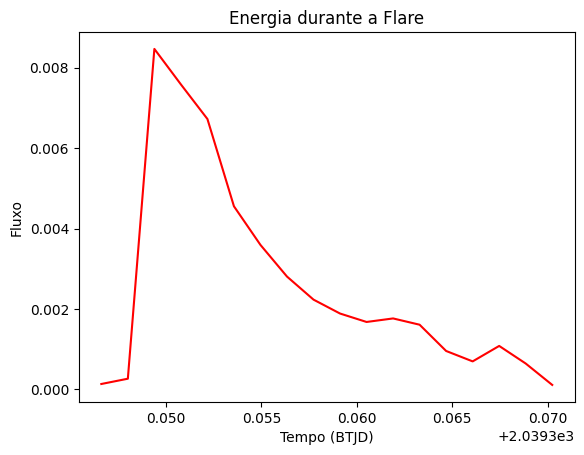

In [12]:
flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

0.013063599999999953
0.008449539999999978


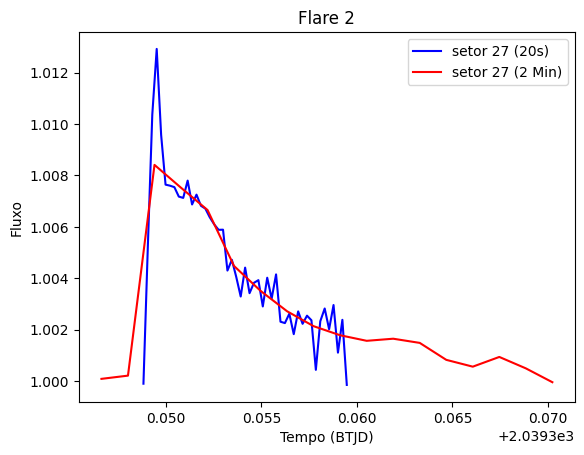

In [13]:

# Vetor 1
vetor1 = np.array([1.0000907, 1.0002159, 1.0084099, 1.0075209, 1.0066546, 1.004478,
                   1.0035108, 1.0027177, 1.002138, 1.0017859, 1.0015697, 1.0016514,
                   1.0014888, 1.0008297, 1.0005645, 1.0009425, 1.0004987, 0.99996036])

# Vetor 2
vetor2 = np.array([2039.34662016, 2039.34800909, 2039.34939801, 2039.35078694,
                   2039.35217587, 2039.3535648, 2039.35495372, 2039.35634265,
                   2039.35773158, 2039.3591205, 2039.36050943, 2039.36189836,
                   2039.36328729, 2039.36467621, 2039.36606514, 2039.36745407,
                   2039.36884299, 2039.37023192])

fluxo_flare2 = [0.9999023, 1.005268, 1.010363, 1.0129184, 1.0095774, 1.0076416,
                   1.0076016, 1.007543, 1.0071762, 1.0071266, 1.0077991, 1.0068709,
                   1.0072526, 1.0068207, 1.0067102, 1.006372, 1.0060978, 1.0058851,
                   1.0058903, 1.004301, 1.0047196, 1.0040479, 1.0032917, 1.0044147,
                   1.003422, 1.0038242, 1.003928, 1.0029064, 1.0040231, 1.0032089,
                   1.0041517, 1.0023125, 1.0022587, 1.0026233, 1.0018284, 1.0027134,
                   1.0022305, 1.0025467, 1.002369, 1.0004408, 1.0023297, 1.0028262,
                   1.0020202, 1.0029607, 1.00111, 1.002386, 0.9998548]

tempo_flare2 = [2039.34881929, 2039.34905078, 2039.34928227, 2039.34951376,
                   2039.34974525, 2039.34997673, 2039.35020822, 2039.35043971,
                   2039.3506712, 2039.35090268, 2039.35113417, 2039.35136566,
                   2039.35159715, 2039.35182864, 2039.35206012, 2039.35229161,
                   2039.3525231, 2039.35275459, 2039.35298608, 2039.35321756,
                   2039.35344905, 2039.35368054, 2039.35391203, 2039.35414352,
                   2039.354375, 2039.35460649, 2039.35483798, 2039.35506947,
                   2039.35530095, 2039.35553244, 2039.35576393, 2039.35599542,
                   2039.35622691, 2039.35645839, 2039.35668988, 2039.35692137,
                   2039.35715286, 2039.35738435, 2039.35761583, 2039.35784732,
                   2039.35807881, 2039.3583103, 2039.35854178, 2039.35877327,
                   2039.35900476, 2039.35923625, 2039.35946774]




amplitude_flare = max(fluxo_flare2) - min(fluxo_flare2)
amplitude_flare2 = max(vetor1) - min(vetor1)
print(amplitude_flare)
print(amplitude_flare2)

# Plotar os gráficos
plt.plot(tempo_flare2, fluxo_flare2, 'b', label='setor 27 (20s)')
plt.plot(vetor2, vetor1, 'r', label='setor 27 (2 Min)')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Flare 2')

# Adicionar a legenda
plt.legend()

# Mostrar o gráfico
plt.show()